**Central Limit Theorem**  

*Introduction:*  
The central limit theorem is, arguably, the most important result in all of statistics. What it says is:  
Take any population with mean μ and standard deviation σ. It can be any shape at all. Draw a random sample of size n from it. Compute the sample mean. Repeat this many times. The distribution of those sample means will be approximately normal (bell-shaped), and this approximation gets better as n increases.  
In simple terms, no matter how large or weird or 'non-normal' original data is, the means of large enough samples will always look normal.  

*Example:*  
Let's take a simple daily-life example to understand this. Suppose you have a very skewed distribution, say the time between bus arrivals. Now, these are almost always short, and could occasionally be very long as well. This looks nothing like a bell curve. Now:  
1. Draw 50 bus arrival times at random and calculate their mean.
2. Repeat step 1 10,000 times.
3. Plot these 10,000 means.
The distribution of these means will look like a bell curve. This is the central limit theorem.  

*Conclusion:*  
There are two key takeaways from the CLT, and we are going to verify them using this simulation.  
1. The mean of sample means = The population mean.  
   Mathematically, mean(x̄) = μ
2. The standard deviation of sample means (aka the standard error) shrinks as n grows.  
   Mathematically, std(x̄) = σ / √n
   This second fact is why larger samples give more reliable estimates. As you can clearly see from the mathematical expression, the standard deviation decreases as the number of samples (n) increases. 

**What is this simulation about?**  
Thi simulation verifies the central limit theorem, and ultimately concluded that irrespective of the original distribution, the sample means become approximately normal (bell-curve). To prove this, we will start by taking the three most common distribution functions:  
1. Uniform Function: f(x) = 1 / (b − a)
2. Exponential Function: f(x) = (λe) ** (−λx)
3. Gaussian / Normal Function: f(x)= ( 1/σ√2π )( ​e**(−(x−μ)** 2/2σ** 2​ )
4. A bimodal function which will be created by using two normal distributions

In [1]:
#importing all the required libraries
import random
import math
import matplotlib.pyplot as plt
%matplotlib inline
random.seed(42)

*Python random functions that are going to be used in this simulation*  
1. `random.uniform(a, b)` : returns a random float uniformly between a and b
2. `random.expovariate(lambda)` : returns a random float from exponential distribution with rate λ.
3. `random.gauss(miu, sigma)` : returns a random float from normal distribution

**Defining the parameters and functions**  
Feel free to tweak them and see the changes in the distributions!

In [17]:
#General parameters
trials = 10000          #no. of samples per sample size
sample_size = [1, 10, 30, 100]      #for 2X2 CLT grid
compare = 30                            #for the comparison plot

*Exponential Distribution*

In [18]:
lambd = 0.5                            #rate parameter
theoretical_mean_e = 1 / lambd           #mean = 1/λ
theoretical_std_e = 1 / lambd            #std_dev = 1/λ (property of exponential)

def exponential():
    return random.expovariate(lambd)

*Why exponential?*  
Our aim with this simulation is to verify whether or not any distribution function, whatever it is, can ultimately demonstrate CLT.  
The exponential distribution is strongly right-skewed. Most values are small but there is a long tail stretching to the right. It looks nothing like a bell curve, and thus, this makes it the best choice for demonstrating the CLT because the transformation is the most visually dramatic. You can watch an obviously non-normal distribution become a bell curve as n increases.

*Uniform Distribution*  


In [20]:
a = 0
b = 10         
theoretical_mean_u = (a + b) / 2
theoretical_std_u = (b - a) / math.sqrt(12)

def uniform():
    return random.uniform(a, b)

*Why uniform?*  
Again, the visual representation of a flat distribution where all the values between a and b being equally likely producing a bell curve is our second stress test for CLT. 

*Normal / Gaussian Distribution*

In [21]:
miu = 5.0
sigma = 2.0
theoretical_mean_n = miu
theoretical_std_n = sigma

def normal():
    return random.gauss(miu, sigma)

*Why gaussian?*  
The normal distribution is the baseline. Since the CLT says sample means converge to a normal distribution, if your source is already normal, the sample means should be normal at every sample size.

**Core Functions: Sampling one mean function, and then collecting them to compute the mean and standard deviation**

In [22]:
def one_sample(n, func):
    sample = [func() for _ in range(n)]
    return sum(sample) / len(sample)

def many_samples(n, func, trials):
    return [one_sample(n, func) for _ in range(trials)]

def mean_and_std(values):
    n = len(values)
    miu = sum(values) / n
    var = sum((x - miu)**2 for x in values) / n
    std = math.sqrt(var)
    return miu, std

**Running the simulation for each function and printing the results**

In [23]:
parameters = [
    ('Exponential', exponential, theoretical_mean_e, theoretical_std_e),
    ('Uniform', uniform, theoretical_mean_u, theoretical_std_u),
    ('Normal', normal, theoretical_mean_n, theoretical_std_n),
]

for name, func, mean, std in parameters:
    print(f"\n{name} (μ={mean:.2f}, σ={std:.2f})")
    print(f"{'n':>6}  {'Simulated mean':>10}  {'Simulated SE':>10}  {'Theoretical SE':>12}")
    for i in sample_size:
        means = many_samples(i, func, trials)
        sim_mean, sim_se = mean_and_std(means)
        theory_se = std / math.sqrt(i)
        print(f"{i:>6}  {sim_mean:>10.4f}  {sim_se:>10.4f}  {theory_se:>12.4f}")

print("SE = Standard Error")


Exponential (μ=2.00, σ=2.00)
     n  Simulated mean  Simulated SE  Theoretical SE
     1      2.0244      2.0242        2.0000
    10      2.0015      0.6258        0.6325
    30      2.0003      0.3643        0.3651
   100      2.0035      0.2012        0.2000

Uniform (μ=5.00, σ=2.89)
     n  Simulated mean  Simulated SE  Theoretical SE
     1      4.9777      2.8775        2.8868
    10      5.0012      0.9104        0.9129
    30      5.0016      0.5293        0.5270
   100      4.9987      0.2890        0.2887

Normal (μ=5.00, σ=2.00)
     n  Simulated mean  Simulated SE  Theoretical SE
     1      5.0212      2.0143        2.0000
    10      5.0096      0.6318        0.6325
    30      4.9939      0.3683        0.3651
   100      5.0007      0.2015        0.2000
SE = Standard Error


From the above table about standard errors and simulated means, we can come at the following conclusions:  
1. Sample means are centred correctly (i.e., they are unbiased)
2. SE gets smaller as n increases. This means that larger samples give more stable estimates.​


**Visualisations**

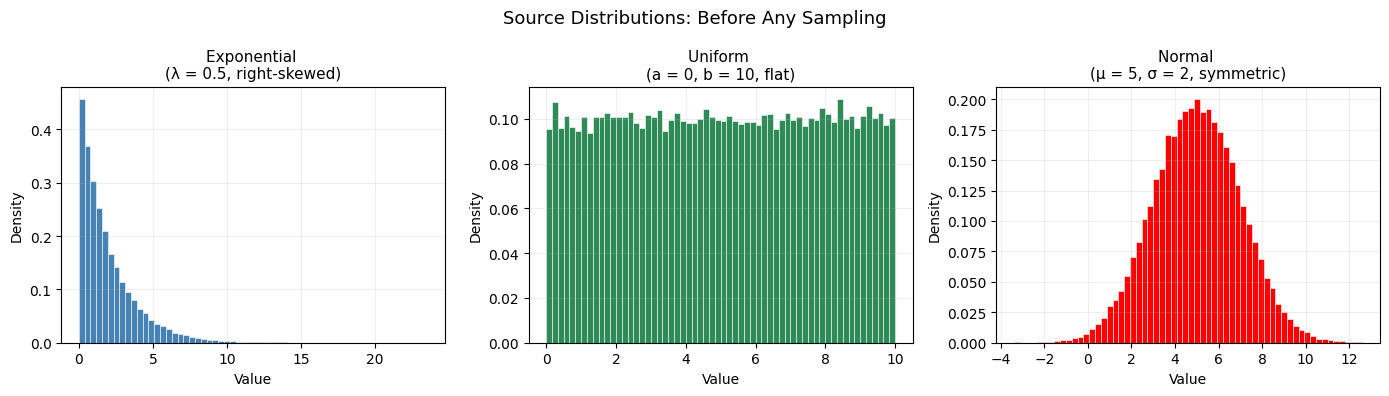

In [24]:
val = {
    'Exponential \n(λ = 0.5, right-skewed)': [exponential() for _ in range(50000)],
    'Uniform \n(a = 0, b = 10, flat)': [uniform() for _ in range(50000)],
    'Normal \n(μ = 5, σ = 2, symmetric)': [normal() for _ in range(50000)],
}
colours = ['steelblue', 'seagreen', 'red']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, data), colour in zip(axes, val.items(), colours):
    ax.hist(data, 
            bins=60, 
            color=colour, 
            edgecolor='white', 
            linewidth=0.4, 
            density=True
            )
    
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.2)

fig.suptitle('Source Distributions: Before Any Sampling', fontsize=13)

plt.tight_layout()
plt.show()

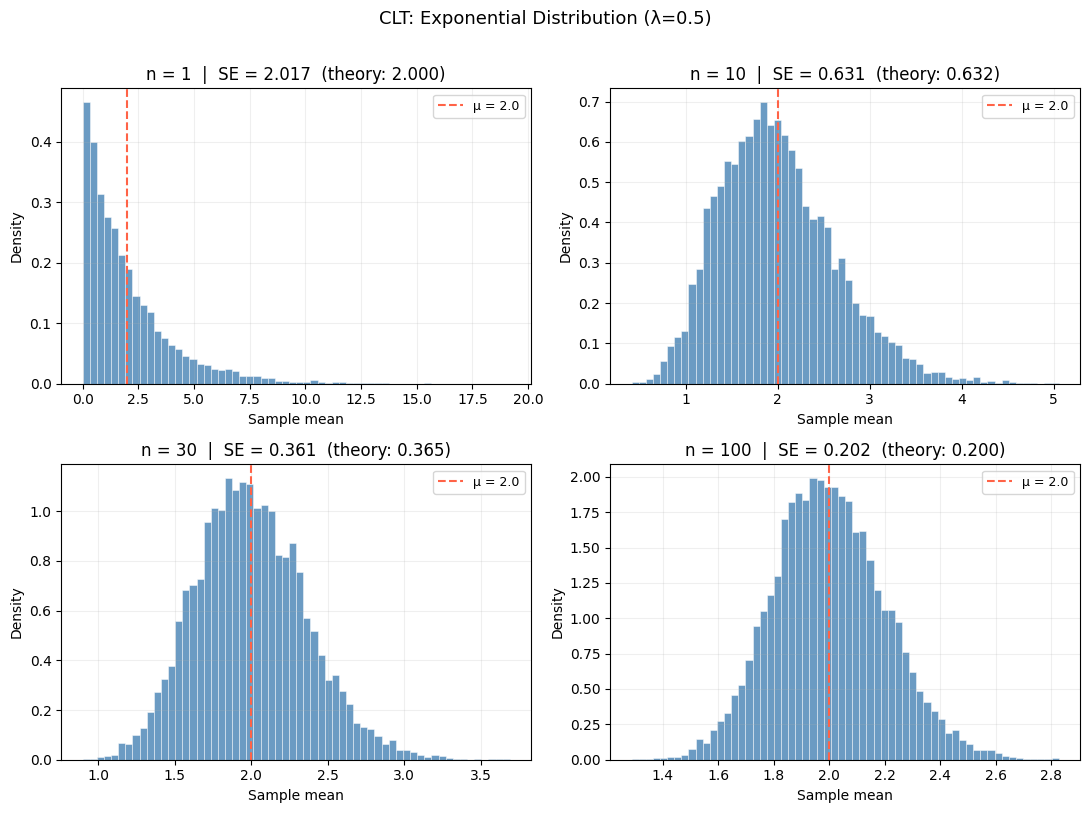

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, n in enumerate(sample_size):
    means = many_samples(n, exponential, trials)
    sim_mean, sim_se = mean_and_std(means)

    axes[i].hist(means, 
                   bins=60, 
                   color='steelblue', 
                   edgecolor='white',
                   linewidth=0.4, 
                   density=True, 
                   alpha=0.8
                   )
    
    axes[i].axvline(x = theoretical_mean_e, 
                      color='tomato', 
                      linestyle='--',
                      linewidth=1.5, 
                      label=f'μ = {theoretical_mean_e}'
                      )
    
    axes[i].set_title(f'n = {n}  |  SE = {sim_se:.3f}  (theory: {theoretical_std_e/math.sqrt(n):.3f})')
    axes[i].set_xlabel('Sample mean')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.2)

fig.suptitle('CLT: Exponential Distribution (λ=0.5)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

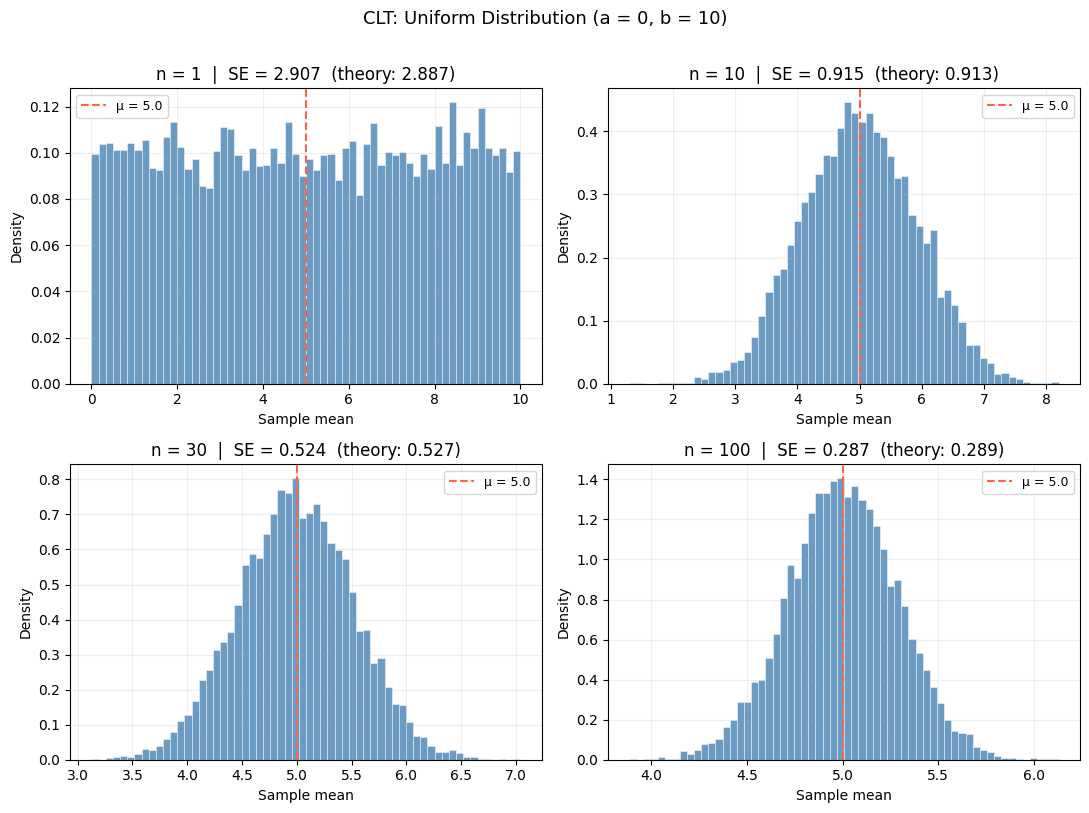

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, n in enumerate(sample_size):
    means = many_samples(n, uniform, trials)
    sim_mean, sim_se = mean_and_std(means)

    axes[i].hist(means, 
                   bins=60, 
                   color='steelblue', 
                   edgecolor='white',
                   linewidth=0.4, 
                   density=True, 
                   alpha=0.8
                   )
    
    axes[i].axvline(x = theoretical_mean_u, 
                      color='tomato', 
                      linestyle='--',
                      linewidth=1.5, 
                      label=f'μ = {theoretical_mean_u}'
                      )
    
    axes[i].set_title(f'n = {n}  |  SE = {sim_se:.3f}  (theory: {theoretical_std_u/math.sqrt(n):.3f})')
    axes[i].set_xlabel('Sample mean')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.2)

fig.suptitle('CLT: Uniform Distribution (a = 0, b = 10)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

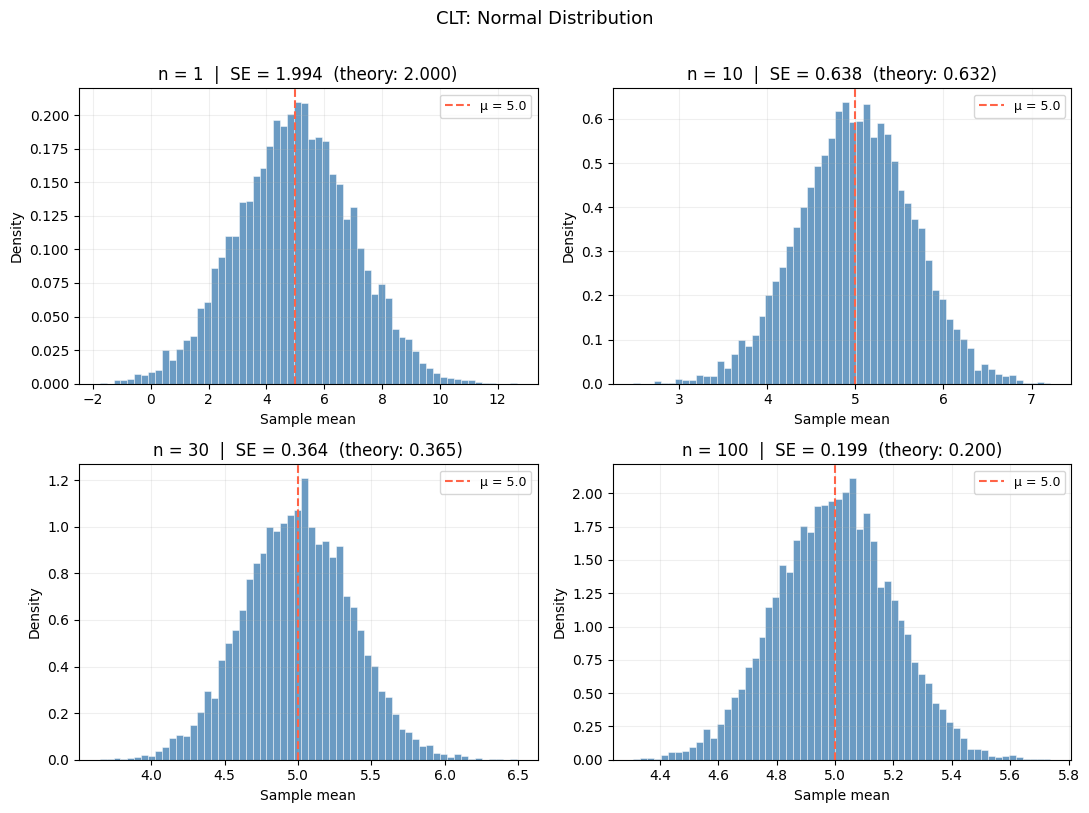

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, n in enumerate(sample_size):
    means = many_samples(n, normal, trials)
    sim_mean, sim_se = mean_and_std(means)

    axes[i].hist(means, 
                   bins=60, 
                   color='steelblue', 
                   edgecolor='white',
                   linewidth=0.4, 
                   density=True, 
                   alpha=0.8
                   )
    
    axes[i].axvline(x = theoretical_mean_n, 
                      color='tomato', 
                      linestyle='--',
                      linewidth=1.5, 
                      label=f'μ = {theoretical_mean_n}'
                      )
    
    axes[i].set_title(f'n = {n}  |  SE = {sim_se:.3f}  (theory: {theoretical_std_n/math.sqrt(n):.3f})')
    axes[i].set_xlabel('Sample mean')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.2)

fig.suptitle('CLT: Normal Distribution',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

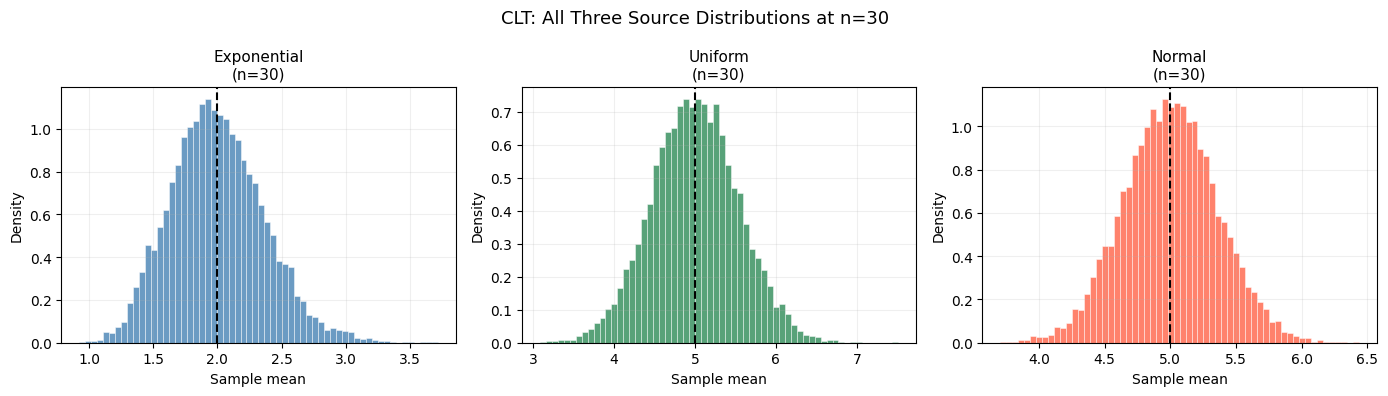

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs_plot = [
    ('Exponential', exponential, theoretical_mean_e, 'steelblue'),
    ('Uniform', uniform, theoretical_mean_u, 'seagreen'),
    ('Normal', normal,theoretical_mean_n,'tomato'),
]

for ax, (name, func, mean, colour) in zip(axes, configs_plot):
    means = many_samples(30, func, trials)
    ax.hist(means, 
            bins=60, 
            color=colour, 
            edgecolor='white',
            linewidth=0.4, 
            density=True, 
            alpha=0.8
            )
    
    ax.axvline(x = mean, 
               color='black', 
               linestyle='--', 
               linewidth=1.5
               )
    
    ax.set_title(f'{name}\n(n=30)', fontsize=11)
    ax.set_xlabel('Sample mean')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.2)

fig.suptitle('CLT: All Three Source Distributions at n=30',
             fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
N = [i for i in range(1, 201, 5)]
c  = {'Exponential': 'steelblue', 'Uniform': 'seagreen', 'Normal': 'tomato'}
config = [
    ('Exponential', exponential, theoretical_std_e),
    ('Uniform', uniform, theoretical_std_e),
    ('Normal', normal, theoretical_std_e),
]

fig, ax = plt.subplots(figsize=(10, 5))

for name, func, std in config:
    vals = []
    theory_vals = [std / math.sqrt(n) for n in N]

    for n in N:
        means = many_samples(n, func, trials=2000)
        _, sim_se = mean_and_std(means)
        vals.append(sim_se)

    ax.plot(N, 
            vals,    
            'o', 
            color = c[name],
            markersize = 3, 
            alpha = 0.6, 
            label = f'{name} (simulated)'
            )
    
    ax.plot(N, 
            theory_vals, 
            '--', 
            color = c[name],
            linewidth = 1.5
            )

ax.set_xlabel('Sample size (n)')
ax.set_ylabel('Standard Error')
ax.set_title('Standard Error vs. Sample Size')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()